In [1]:
import pennylane as qml
import numpy as np
import sys
import pennylane.utils
from pennylane.utils import decompose_hamiltonian
sys.path.append('..')
from QHyper.optimizers.CEM import CEM
from QHyper.optimizers.random import Random
from QHyper.optimizers.qml_gradient_descent import QmlGradientDescent
from QHyper.solvers.QAOA.core import QAOA

In [2]:
from QHyper.problems.Workflowtest import WorkflowtestProblem

In [3]:
wft = WorkflowtestProblem()

6.0*x0 + 8.0*x1 + 8.0*x2 + 3.0*x3 + 4.0*x4 + 4.0*x5 + 12.0*x6 + 16.0*x7 + 16.0*x8
[x0**2 + 2*x0*x1 + 2*x0*x2 - 2*x0 + x1**2 + 2*x1*x2 - 2*x1 + x2**2 - 2*x2 + x3**2 + 2*x3*x4 + 2*x3*x5 - 2*x3 + x4**2 + 2*x4*x5 - 2*x4 + x5**2 - 2*x5 + x6**2 + 2*x6*x7 + 2*x6*x8 - 2*x6 + x7**2 + 2*x7*x8 - 2*x7 + x8**2 - 2*x8, 36.0*x0**2 + 24.0*x0*x1 + 48.0*x0*x10 + 24.0*x0*x11 + 12.0*x0*x12 + 48.0*x0*x2 + 36.0*x0*x3 + 12.0*x0*x4 + 24.0*x0*x5 + 144.0*x0*x6 + 48.0*x0*x7 + 96.0*x0*x8 + 96.0*x0*x9 - 228.0*x0 + 4.0*x1**2 + 16.0*x1*x10 + 8.0*x1*x11 + 4.0*x1*x12 + 16.0*x1*x2 + 12.0*x1*x3 + 4.0*x1*x4 + 8.0*x1*x5 + 48.0*x1*x6 + 16.0*x1*x7 + 32.0*x1*x8 + 32.0*x1*x9 - 76.0*x1 + 16*x10**2 + 16*x10*x11 + 8*x10*x12 + 32.0*x10*x2 + 24.0*x10*x3 + 8.0*x10*x4 + 16.0*x10*x5 + 96.0*x10*x6 + 32.0*x10*x7 + 64.0*x10*x8 + 64*x10*x9 - 152*x10 + 4*x11**2 + 4*x11*x12 + 16.0*x11*x2 + 12.0*x11*x3 + 4.0*x11*x4 + 8.0*x11*x5 + 48.0*x11*x6 + 16.0*x11*x7 + 32.0*x11*x8 + 32*x11*x9 - 76*x11 + x12**2 + 8.0*x12*x2 + 6.0*x12*x3 + 2.0*x12*x4 + 4

In [4]:
solver = QAOA(
    problem=wft,
    platform="pennylane",
    optimizer=QmlGradientDescent(3, qml.QNGOptimizer()),
    layers=1,
    weights=[1.0, 20.0, 10.0],
    angles=[[0.5]*1, [0.5]*1],
    # mixer: str=,
    # backend=
)

In [22]:
H=solver.get_cost_operator()

In [25]:
H

<Hamiltonian: terms=92, wires=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]>


In [26]:
Hmat = qml.utils.sparse_hamiltonian(H)

In [27]:
Hmat

<8192x8192 sparse matrix of type '<class 'numpy.complex128'>'
	with 8187 stored elements in Compressed Sparse Row format>

In [57]:
for i in range((pow(2,13)-1)*(pow(2,13)-1)):
    b = bin(i)[2:]
    print(str(b).zfill(13), Hmat[i,i]+2714)


0000000000000 (2714+0j)
0000000000001 (2344+0j)
0000000000010 (1994+0j)
0000000000011 (1664+0j)
0000000000100 (1354+0j)
0000000000101 (1064+0j)
0000000000110 (794+0j)
0000000000111 (544+0j)
0000000001000 (314+0j)
0000000001001 (104+0j)
0000000001010 (-86+0j)
0000000001011 (-256+0j)
0000000001100 (-406+0j)
0000000001101 (-536+0j)
0000000001110 (-646+0j)
0000000001111 (-736+0j)
0000000010000 (310+0j)
0000000010001 (100+0j)
0000000010010 (-90+0j)
0000000010011 (-260+0j)
0000000010100 (-410+0j)
0000000010101 (-540+0j)
0000000010110 (-650+0j)
0000000010111 (-740+0j)
0000000011000 (-810+0j)
0000000011001 (-860+0j)
0000000011010 (-890+0j)
0000000011011 (-900+0j)
0000000011100 (-890+0j)
0000000011101 (-860+0j)
0000000011110 (-810+0j)
0000000011111 (-740+0j)
0000000100000 (1350+0j)
0000000100001 (1060+0j)
0000000100010 (790+0j)
0000000100011 (540+0j)
0000000100100 (310+0j)
0000000100101 (100+0j)
0000000100110 (-90+0j)
0000000100111 (-260+0j)
0000000101000 (-410+0j)
0000000101001 (-540+0j)
00000

IndexError: row index (8192) out of range

In [45]:

s=qml.eigvals(H)

C:\Users\kzajac\AppData\Roaming\Python\Python310\site-packages\pennylane\ops\functions\eigvals.py:108: UserWarning: For Hamiltonians, the eigenvalues will be computed numerically. This may be computationally intensive for a large number of wires.Consider using a sparse representation of the Hamiltonian with qml.SparseHamiltonian.
  warnings.warn(


In [46]:
s

array([-3648., -3647., -3647., ..., 10273., 10337., 11087.])

In [31]:
for i in range(13*13):
    print (i, Hmat[i,i])
    print(s[i])

0 0j
-3648.0
1 (-370+0j)
-3647.0
2 (-720+0j)
-3647.0
3 (-1050+0j)
-3646.0
4 (-1360+0j)
-3646.0
5 (-1650+0j)
-3646.0
6 (-1920+0j)
-3646.0
7 (-2170+0j)
-3645.0
8 (-2400+0j)
-3645.0
9 (-2610+0j)
-3644.0
10 (-2800+0j)
-3644.0
11 (-2970+0j)
-3644.0
12 (-3120+0j)
-3644.0
13 (-3250+0j)
-3643.0
14 (-3360+0j)
-3643.0
15 (-3450+0j)
-3643.0
16 (-2404+0j)
-3643.0
17 (-2614+0j)
-3642.0
18 (-2804+0j)
-3642.0
19 (-2974+0j)
-3642.0
20 (-3124+0j)
-3642.0
21 (-3254+0j)
-3642.0
22 (-3364+0j)
-3642.0
23 (-3454+0j)
-3642.0
24 (-3524+0j)
-3642.0
25 (-3574+0j)
-3641.0
26 (-3604+0j)
-3640.0
27 (-3614+0j)
-3640.0
28 (-3604+0j)
-3639.0
29 (-3574+0j)
-3639.0
30 (-3524+0j)
-3638.0
31 (-3454+0j)
-3638.0
32 (-1364+0j)
-3638.0
33 (-1654+0j)
-3638.0
34 (-1924+0j)
-3638.0
35 (-2174+0j)
-3637.0
36 (-2404+0j)
-3637.0
37 (-2614+0j)
-3637.0
38 (-2804+0j)
-3636.0
39 (-2974+0j)
-3636.0
40 (-3124+0j)
-3636.0
41 (-3254+0j)
-3636.0
42 (-3364+0j)
-3636.0
43 (-3454+0j)
-3636.0
44 (-3524+0j)
-3636.0
45 (-3574+0j)
-3636.0
46 (-360

In [59]:
#funkcja wyliczająca wartość H dla stanu |num>
dev = qml.device("default.qubit", wires=13)


@qml.qnode(dev)
def circuit(num):
    i=0
    while num>=1:
        if num%2==1:    
            qml.PauliX(i)
        num=num//2
        i=i+1
    return qml.expval(H)


In [65]:
mydict={}
qsize=2
smaller_size=pow(2,qsize)
import random
ran=random.sample(range(0, pow(2,13)), smaller_size)
for i in range(0,smaller_size):
    x=ran[i]
    y=circuit(x).item(0)+2714
    print(str(bin(x)[2:]).zfill(13),str(bin(x)[2:]).zfill(13)[::-1], y)
    print(int(str(bin(x)[2:]).zfill(13)[::-1]))
    mydict[x]=y



0111011000010 0100001101110 810.0
100001101110
0010011110001 1000111100100 126.0
1000111100100
1100110101011 1101010110011 -33.0
1101010110011
0010011000000 0000001100100 -858.0
1100100


In [ ]:
str=

In [ ]:
0010101101100

In [11]:
np.array(list(dict(sorted(mydict.items())).values()))

array([-1661., -3004., -2812., -1660.])

In [12]:
HA = np.zeros((smaller_size, smaller_size), float)

np.fill_diagonal(HA, np.array(list(dict(sorted(mydict.items())).values())))



In [13]:
coeffs, obs_list = decompose_hamiltonian(HA)
coeffs

[-2284.25, 47.75, -48.25, 623.75]

In [14]:
HAd=qml.Hamiltonian(coeffs,obs_list)
HAd

  (-2284.25) [I0 I1]
+ (-48.25) [Z0 I1]
+ (47.75) [I0 Z1]
+ (623.75) [Z0 Z1]


In [29]:
import pennylane.qaoa.layers
from pennylane.qaoa.layers import cost_layer,mixer_layer
import pennylane.qaoa
from pennylane.qaoa import x_mixer


@qml.qnode(dev)
def circuitqaoa(p,gamma,alpha, Hi,size):
    dev = qml.device('default.qubit', wires=size)
    for i in range(0,size):
        qml.Hadamard(wires=i)
    for ind in range(p):   
        cost_layer(gamma[ind], Hi)
        mixer_h = x_mixer(range(0,size))
        mixer_layer(alpha[ind], mixer_h)

    return qml.expval(Hi)

In [30]:
p=1
gamma=0.1
alpha=0.1
def maly(params):
    return circuitqaoa(p,params[0],params[1],HAd,qsize)

def duzy(params):
    return circuitqaoa(p,params[0],params[1],H,13)

In [40]:
p=5
betat=[]
gammat=[]
a1=[1.04,0.98,0.94,0.88,1.09]
a2=[0.92,1.23,1.58,2.32,5.25]
b1=[1.06,1.05,1.05,1.03,1]
b2=[2.07,2.04,1.96,1.83,2.0]
for i in range(5):
    print(i)
    betat.append(np.pi/(a1[i]*13+a2[i])-0.3)
    gammat.append(b1[i]*np.pi-b2[i]*betat[i]-0.1)
print(betat)
print(gammat)

circuitqaoa(p,gammat,betat,H,13)

0
1
2
3
4
[-0.08243818188436333, -0.07511863610667194, -0.0723483584355222, -0.0716865804077185, -0.13822900856901169]
[3.400735249305813, 3.3519143039268933, 3.340475068802906, 3.267026875343612, 3.3180506707278163]


tensor(-1733.35290973, requires_grad=True)

In [ ]:
p=5
betat=[]
gammat=[]
a1=[1.04,0.98,0.94,0.88,1.09]
a2=[0.92,1.23,1.58,2.32,5.25]
b1=[1.06,1.05,1.05,1.03,1]
b2=[2.07,2.04,1.96,1.83,2.0]
for i in range(5):
    print(i)
    betat.append(np.pi/(a1[i]*13+a2[i])-0.3)
    gammat.append(b1[i]*np.pi-b2[i]*betat[i]-0.1)
print(betat)
print(gammat)

circuitqaoa(p,gammat,betat,H,13)

In [41]:
duzy([gammat,betat])

tensor(-1733.35290973, requires_grad=True)

In [20]:
maly([0.1,0.1])

tensor(-2097.82808571, requires_grad=True)

In [45]:
from pennylane import GradientDescentOptimizer, QNGOptimizer
from pennylane import numpy as np
optimizer = QNGOptimizer(stepsize=0.005)
steps = 100
params = np.array([gammat, betat], requires_grad=True)
for i in range(steps):
    params,cost = optimizer.step_and_cost(duzy, params)
    print(params,cost)

print("Optimal Parameters")
print(params)

ValueError: The objective function must either be encoded as a single QNode or an ExpvalCost object for the natural gradient to be automatically computed. Otherwise, metric_tensor_fn must be explicitly provided to the optimizer.

In [40]:
optimizer = AdagradOptimizer(stepsize=0.01)
steps = 100
params = np.array([6.1, 4.2], requires_grad=True)
for i in range(steps):
    params,cost = optimizer.step_and_cost(maly, params)
    print(params,cost)

print("Optimal Parameters")
print(params)

[6.09 4.19] -1725.6118540399152
[6.08383954 4.1800361 ] -1630.871296588437
[6.07488442 4.17355332] -1697.02153230013
[6.08376961 4.16750963] -1813.9966350384066
[6.07851234 4.16223927] -1726.1063838932714
[6.08408    4.16643838] -1807.368252737359
[6.08696471 4.1635214 ] -1710.6358798982315
[6.09095212 4.1578987 ] -1759.27977630491
[6.08881944 4.15472423] -1792.3551228091458
[6.08938211 4.15361482] -1776.8809590412309
[6.08674289 4.15122382] -1820.0130973462792
[6.08837087 4.14745432] -1685.5792121884733
[6.08920559 4.14442815] -1671.8997171211004
[6.09029783 4.14168643] -1838.1339874322505
[6.09482264 4.13866182] -1703.7565905112072
[6.09274291 4.13551783] -1794.3450620548222
[6.08611661 4.1317182 ] -1815.2001021258993
[6.08623273 4.13256028] -1825.4485079076653
[6.0851423  4.13342965] -1816.051241172597
[6.08015968 4.13359026] -1613.2661674638953
[6.08214992 4.13501537] -1854.3840436717255
[6.08162962 4.13307842] -1960.581669309207
[6.0815956  4.13128565] -1915.542593506452
[6.081489

C:\Users\kzaja\AppData\Local\Temp\ipykernel_30992\2592432005.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


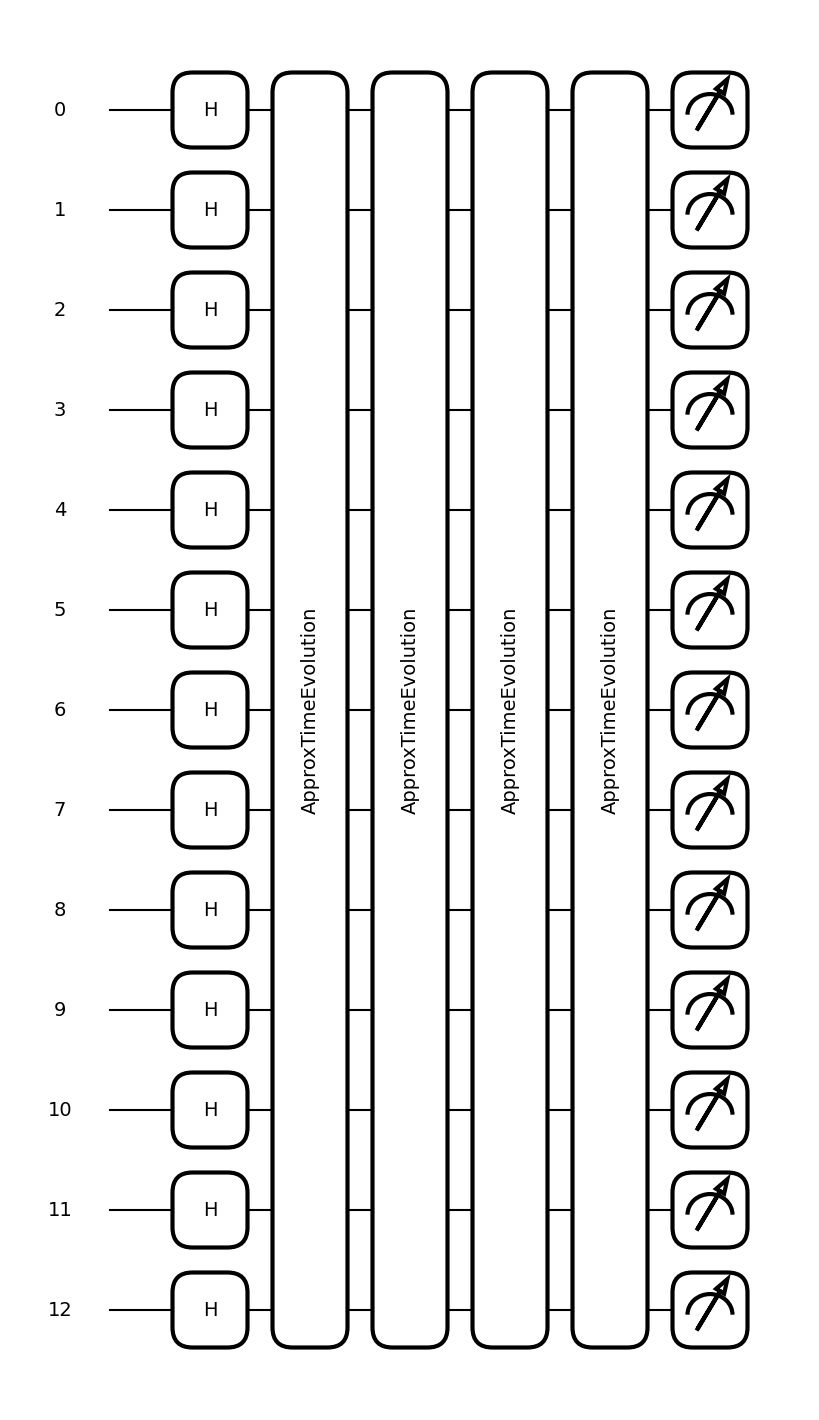

In [81]:

import matplotlib
fig, ax = qml.draw_mpl(circuitqaoa)(2,0.1,0.1,H,13)
fig.show()